# DDM Weibull Collapsing Bound Analysis
## nxx1, seed=42, gain=1.0
Model: v ~ 1 + coherence (Weibull collapsing bound)

In [ ]:
# Set gain level here — change this to analyze different gains
GAIN = 1.0  # options: 0.8, 1.0, 1.2

BASE = '/Users/aliciasmacbookair/Desktop/rnn_hssm_output'
MODEL_PATH = f'{BASE}/ddm_weibull_nxx1_s42_g{GAIN}'
PPC_PATH   = f'{BASE}/ddm_weibull_nxx1_s42_g{GAIN}_ppc.png'
QPP_PATH   = f'{BASE}/ddm_weibull_nxx1_s42_g{GAIN}_qpp.png'
DATA_PATH  = f'{BASE}/hssm_ready_nxx1_s42_g{GAIN}.parquet'

In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import xarray as xr
%matplotlib inline

In [ ]:
import xarray as xr
idata = xr.open_datatree(MODEL_PATH)
print(idata)

## Model Summary

In [ ]:
posterior = idata.posterior
params = ['v_Intercept', 'v_coherence', 'a', 'z', 't']
summary_data = []
for param in params:
    data = posterior[param].values  # shape: (chains, draws)
    flat = data.flatten()
    # Compute R-hat using split-chain method
    n_chains, n_draws = data.shape
    chain_means = data.mean(axis=1)
    chain_vars = data.var(axis=1, ddof=1)
    W = chain_vars.mean()  # within-chain variance
    B = n_draws * chain_means.var(ddof=1)  # between-chain variance
    var_hat = (1 - 1/n_draws) * W + B/n_draws
    rhat = np.sqrt(var_hat / W) if W > 0 else np.nan
    summary_data.append({
        'parameter': param,
        'mean': flat.mean(),
        'sd': flat.std(),
        'hdi_3%': np.percentile(flat, 3),
        'hdi_97%': np.percentile(flat, 97),
        'r_hat': rhat,
    })
display(pd.DataFrame(summary_data).set_index('parameter').round(3))
print("\nNote: r_hat < 1.01 indicates good convergence")

## Trial Counts by Coherence Level

In [ ]:
# Load the processed data to show trial counts
import pathlib
data_path = pathlib.Path(DATA_PATH)
if data_path.exists():
    df_counts = pd.read_parquet(data_path)
    summary = df_counts.groupby('coherence').agg(
        n_trials=('response', 'count'),
        n_correct=('response', lambda x: (x==1.0).sum()),
        n_error=('response', lambda x: (x==-1.0).sum()),
        accuracy=('response', lambda x: (x==1.0).mean())
    ).round(3)
    summary.index = summary.index.round(3)
    display(summary)
    print(f"\nTotal trials: {len(df_counts)}")
    print(f"Note: high coherence conditions have very few errors — this explains the large QPP ellipses on the left side")
else:
    print(f"Data file not found at {data_path}")

## Traces

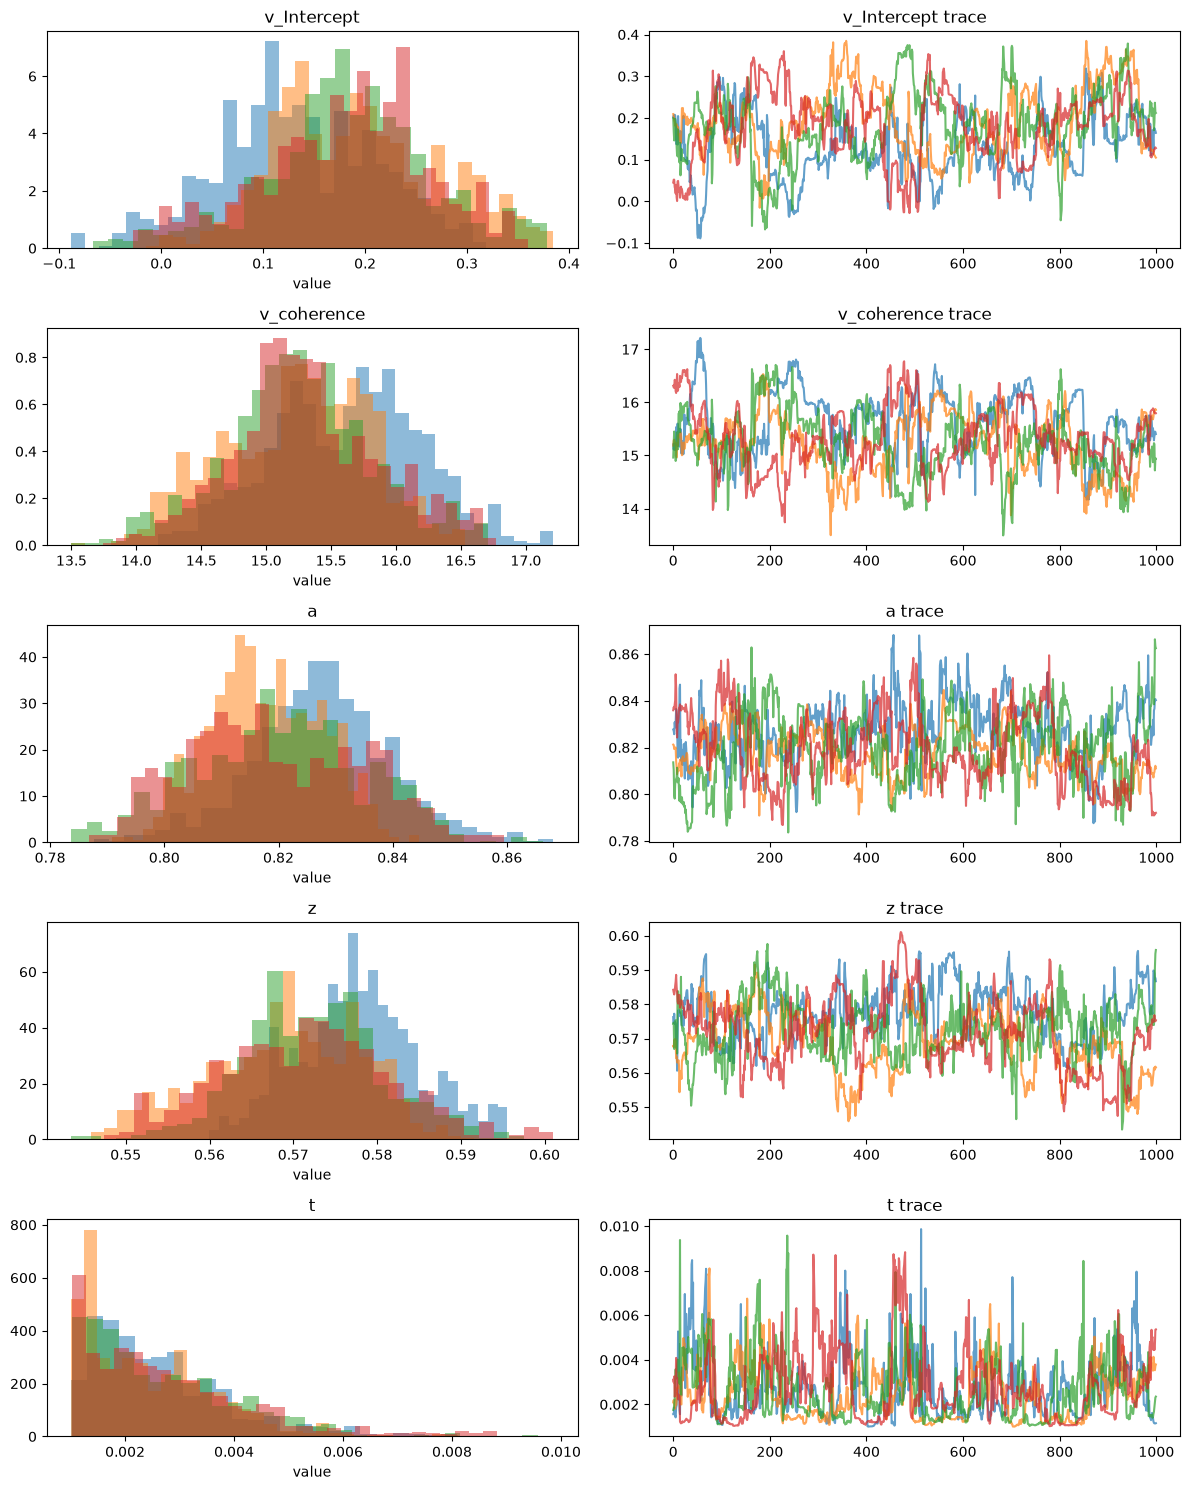

In [12]:
# Plot traces manually
posterior = idata.posterior
params = ['v_Intercept', 'v_coherence', 'a', 'z', 't']
fig, axes = plt.subplots(len(params), 2, figsize=(12, 3*len(params)))
for i, param in enumerate(params):
    data = posterior[param].values  # shape: (chains, draws)
    # KDE plot
    for chain in data:
        axes[i, 0].hist(chain, bins=30, alpha=0.5, density=True)
    axes[i, 0].set_title(param)
    axes[i, 0].set_xlabel('value')
    # Trace plot
    for chain in data:
        axes[i, 1].plot(chain, alpha=0.7)
    axes[i, 1].set_title(f'{param} trace')
plt.tight_layout()
plt.show()

## Posterior Distributions

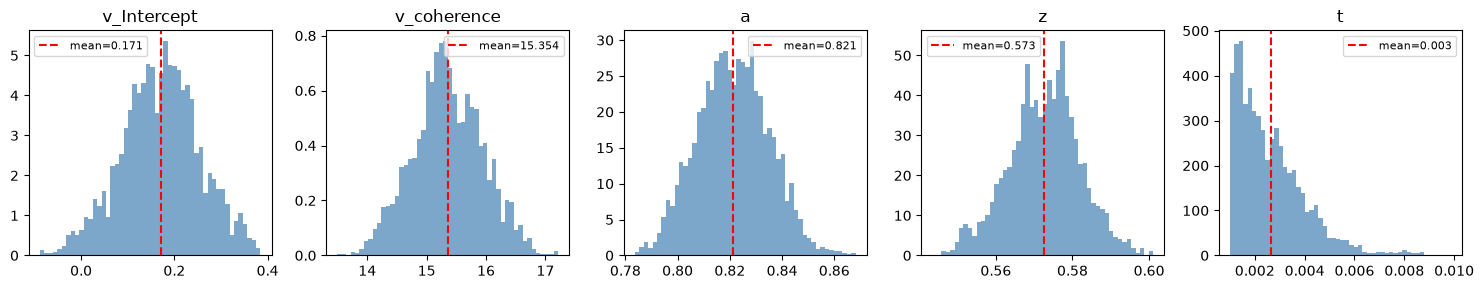

In [13]:
# Plot posterior distributions
posterior = idata.posterior
params = ['v_Intercept', 'v_coherence', 'a', 'z', 't']
fig, axes = plt.subplots(1, len(params), figsize=(15, 3))
for i, param in enumerate(params):
    data = posterior[param].values.flatten()
    axes[i].hist(data, bins=50, density=True, alpha=0.7, color='steelblue')
    axes[i].axvline(data.mean(), color='red', linestyle='--', label=f'mean={data.mean():.3f}')
    axes[i].set_title(param)
    axes[i].legend(fontsize=8)
plt.tight_layout()
plt.show()

## Effect of Coherence on Drift Rate

In [ ]:
import xarray as xr
posterior = idata.posterior
v_intercept = float(posterior['v_Intercept'].mean())
v_coherence = float(posterior['v_coherence'].mean())

coherence_vals = np.linspace(0, 0.15, 100)
drift_rate = v_intercept + coherence_vals * v_coherence

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(coherence_vals, drift_rate, color='blue')
ax.set_xlabel('Coherence (|coh|)')
ax.set_ylabel('Drift rate (v)')
ax.set_title(f'Effect of coherence on drift rate\nnxx1, seed=42, gain={GAIN}')
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

print(f"v_Intercept: {v_intercept:.3f}")
print(f"v_coherence: {v_coherence:.3f}")

## Posterior Predictive Check

In [ ]:
from IPython.display import Image, display
display(Image(PPC_PATH))

## PPC — RT Distribution Split by Correct vs Incorrect (zoomed)

In [ ]:
# Load posterior predictive from idata
pp = idata['posterior_predictive'].to_dataset()
obs = idata['observed_data'].to_dataset()

obs_rt = obs['rt,response'].values[:, 0]
obs_resp = obs['rt,response'].values[:, 1]
pred_rt = pp['rt,response'].values[..., 0].flatten()
pred_resp = pp['rt,response'].values[..., 1].flatten()

obs_correct_rt = obs_rt[obs_resp == 1.0]
obs_error_rt = obs_rt[obs_resp == -1.0]
pred_correct_rt = pred_rt[pred_resp == 1.0]
pred_error_rt = pred_rt[pred_resp == -1.0]

rt_max = np.percentile(obs_rt, 99)
bins = np.linspace(0, rt_max, 50)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].hist(obs_correct_rt, bins=bins, density=True, alpha=0.6, color='blue', label='observed')
axes[0].hist(pred_correct_rt[pred_correct_rt <= rt_max], bins=bins, density=True, alpha=0.4, color='red', label='predicted')
axes[0].set_xlabel('RT (s)')
axes[0].set_ylabel('Density')
axes[0].set_title('Correct Trials')
axes[0].legend()
axes[0].set_xlim(0, rt_max)

axes[1].hist(obs_error_rt, bins=bins, density=True, alpha=0.6, color='blue', label='observed')
axes[1].hist(pred_error_rt[pred_error_rt <= rt_max], bins=bins, density=True, alpha=0.4, color='red', label='predicted')
axes[1].set_xlabel('RT (s)')
axes[1].set_ylabel('Density')
axes[1].set_title('Error Trials')
axes[1].legend()
axes[1].set_xlim(0, rt_max)

plt.suptitle(f'PPC — RT distributions split by correct/error\nnxx1, seed=42, gain={GAIN} (weibull bound)')
plt.tight_layout()
plt.show()

print(f"Observed: {len(obs_correct_rt)} correct, {len(obs_error_rt)} errors")

## Quantile Probability Plot

In [ ]:
display(Image(QPP_PATH))